
# NCCL_IGNORE_CPU_AFFINITY

vLLM launches multiple processes, including EngineCore and Worker_TP processes. Each Worker_TP may spawn additional NCCL/RCCL communication threads to handle GPU communication.

Setting NCCL_IGNORE_CPU_AFFINITY=1 allows these communication threads to bypass CPU affinity constraints imposed by the scheduler (e.g., numactl) and align with the NUMA node of the GPU, but this does not affect the CPU affinity of the existing EngineCore or Worker_TP processes themselves.

Based on the test, setting this variable has no impact on 8-GPU model inference. Since Worker_TP processes exchange data with GPUs, only placing the communication thread closer to the GPU offers little performance benefit when they are on different NUMA nodes.

https://docs.nvidia.com/deeplearning/nccl/user-guide/docs/env.html#nccl-ignore-cpu-affinity
https://rocm.docs.amd.com/projects/rccl/en/latest/how-to/rccl-usage-tips.html#ignoring-cpu-affinity-with-multi-node



In [ ]:
RESULTS (2882 seconds, sampling at the interval of 1 second):

   PID                   COMMAND Current_CPU_Core Current_NUMA_Node CPU_Core_changes    NUMA_changes
     1                 vllm               1               0             294              31
   302           python3.12             165               1               0               0
   303      VLLM::EngineCor              83               0             149               3
   453      VLLM::Worker_TP             166               1             120              10
   454      VLLM::Worker_TP             101               1             154              11
   455      VLLM::Worker_TP              73               0             161               6
   456      VLLM::Worker_TP             145               1             205               7
   457      VLLM::Worker_TP              58               0             129               7
   458      VLLM::Worker_TP              23               0             146               7
   459      VLLM::Worker_TP              24               0             119               7
   460      VLLM::Worker_TP             143               1             175              13


In [29]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy
%matplotlib inline  

In [30]:
df = pd.read_csv("./deepseek_r1_mxfp4_vllm_20260304.csv")

In [31]:
#df.info()
#df.head()

In [32]:
df['base_url'].unique()

array(['http://mi350-vllm-dev.default.svc.cluster.local:80',
       'http://mi350-vllm-latest.default.svc.cluster.local:80',
       'http://mi350-vllm.default.svc.cluster.local:80'], dtype=object)

In [33]:
df['others'].unique()

array(['doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-latest-0.15.1',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal2',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal3',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-1',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-2',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-3',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-1',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-2',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-3'],
      dtype=object)

In [34]:
# All requests are successfully processed
df [ df['failed'] >0 ] 

,mean_ttft_ms,timestamp,output_throughput,max_output_tokens_per_s,median_tpot_ms,median_ttft_ms,std_tpot_ms,p99_tpot_ms,p99_itl_ms,total_output_tokens,...,num_prompts,max_concurrent_requests,date,base_url,endpoint_type,duration,task_id,completed,label,total_token_throughput


In [35]:
case_map = {
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-latest-0.15.1": "vllm-0.15.1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120": "vllm-dev-dsfp4-1120-0",  
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal":  "vllm-dev-dsfp4-1120-1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal2": "vllm-dev-dsfp4-1120-2",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal3": "vllm-dev-dsfp4-1120-3",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-1": "vllm-dev-dsfp4-1120-numa0-1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-2": "vllm-dev-dsfp4-1120-numa0-2",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-3": "vllm-dev-dsfp4-1120-numa0-3",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-1": "vllm-dev-dsfp4-1120-ignore-1",  # NCCL_IGNORE_CPU_AFFINITY=1 
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-2": "vllm-dev-dsfp4-1120-ignore-2",  # NCCL_IGNORE_CPU_AFFINITY=1 
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-ignore-3": "vllm-dev-dsfp4-1120-ignore-3",  # NCCL_IGNORE_CPU_AFFINITY=1     
}

df["case"] = df["others"].map(case_map)

df = df [ df['num_prompts'] <= 40]

In [36]:
color_map = {
    "vllm-0.15.1": "grey",
    "vllm-dev-dsfp4-1120-0": "grey",
    "vllm-dev-dsfp4-1120-1": "grey",    
    "vllm-dev-dsfp4-1120-2": "black",    
    "vllm-dev-dsfp4-1120-3": "black",    
    "vllm-dev-dsfp4-1120-numa0-1": "grey",  
    "vllm-dev-dsfp4-1120-numa0-2": "blue",  
    "vllm-dev-dsfp4-1120-numa0-3": "blue",  
    "vllm-dev-dsfp4-1120-ignore-1": "grey",  
    "vllm-dev-dsfp4-1120-ignore-2": "red",  
    "vllm-dev-dsfp4-1120-ignore-3": "red",  
}

case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3
case: vllm-dev-dsfp4-1120-ignore-2
case: vllm-dev-dsfp4-1120-ignore-3


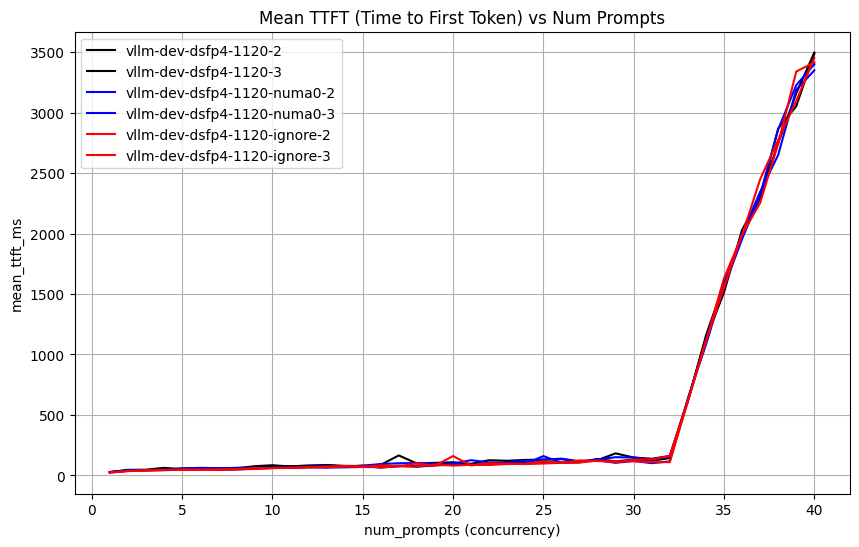

In [37]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
        
    print(f"case: {case}")
    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["mean_ttft_ms"],
        #temp_df["median_ttft_ms"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("mean_ttft_ms")
plt.title("Mean TTFT (Time to First Token) vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()

case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3
case: vllm-dev-dsfp4-1120-ignore-2
case: vllm-dev-dsfp4-1120-ignore-3


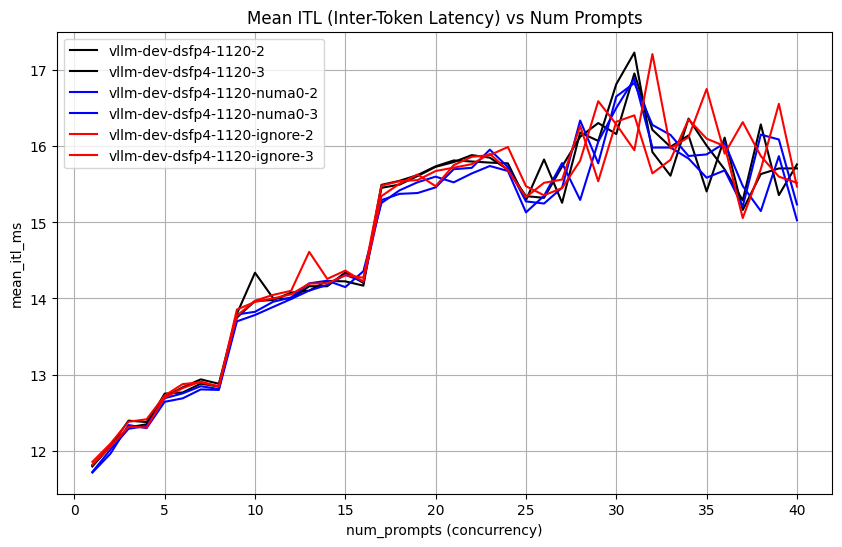

In [38]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
    
    print(f"case: {case}")

    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["mean_itl_ms"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("mean_itl_ms")
plt.title("Mean ITL (Inter-Token Latency) vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()

case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3
case: vllm-dev-dsfp4-1120-ignore-2
case: vllm-dev-dsfp4-1120-ignore-3


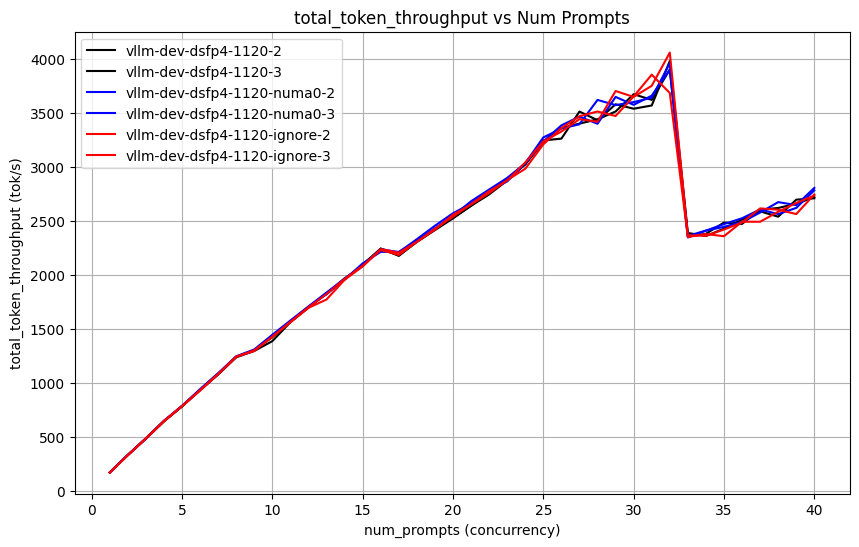

In [39]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
    
    print(f"case: {case}")
    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["total_token_throughput"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("total_token_throughput (tok/s)")
plt.title("total_token_throughput vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()